## Libraries & Data Load

In [1]:
# Importing Libraries & Data Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
from warnings import filterwarnings

filterwarnings('ignore')

In [2]:
# Read the data
df = pd.read_excel('Data/Prediction_data.xlsx', sheet_name='vw_ChurnData')
print(df.shape)
df.head()

(6007, 32)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,78303-AND,Female,35,No,Andhra Pradesh,13,35,NaN,Yes,Yes,...,Bank Withdrawal,106.599998,6428.399902,0.0,0,2515.030029,8943.429688,Churned,Competitor,Competitor offered more data
1,78303-KER,Female,47,Yes,Kerala,14,35,Deal 2,Yes,Yes,...,Bank Withdrawal,26.500000,1698.550049,0.0,0,2191.149902,3889.699951,Stayed,Others,Others
2,78306-HAR,Female,79,No,Haryana,1,21,NaN,Yes,Yes,...,Bank Withdrawal,108.449997,7076.350098,0.0,0,1438.140015,8514.490234,Stayed,Others,Others
3,78312-MAH,Female,46,Yes,Maharashtra,4,27,Deal 2,Yes,Yes,...,Bank Withdrawal,106.150002,6411.250000,0.0,0,598.799988,7010.049805,Stayed,Others,Others
4,78315-TAM,Male,42,No,Tamil Nadu,10,4,NaN,Yes,Yes,...,Credit Card,85.900002,6110.750000,0.0,0,782.640015,6893.390137,Stayed,Others,Others


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6007 non-null   object 
 1   Gender                       6007 non-null   object 
 2   Age                          6007 non-null   int64  
 3   Married                      6007 non-null   object 
 4   State                        6007 non-null   object 
 5   Number_of_Referrals          6007 non-null   int64  
 6   Tenure_in_Months             6007 non-null   int64  
 7   Value_Deal                   2710 non-null   object 
 8   Phone_Service                6007 non-null   object 
 9   Multiple_Lines               6007 non-null   object 
 10  Internet_Service             6007 non-null   object 
 11  Internet_Type                4784 non-null   object 
 12  Online_Security              6007 non-null   object 
 13  Online_Backup     

## Data Preprocessing

In [4]:
# Drop columns that won't be used for prediction
df = df.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)
df.shape

(6007, 29)

In [5]:
# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing', 'Payment_Method'
]

In [6]:
# Encode categorical variables except the target variable
label_encoders = {}

for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

In [8]:
# Manually encode the target variable 'Customer_Status'
df['Customer_Status'] = df['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

In [9]:
df.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,0,35,0,0,13,35,5,1,1,1,...,2,1,0,106.599998,6428.399902,0.0,0,2515.030029,8943.429688,1
1,0,47,1,10,14,35,1,1,1,0,...,2,0,0,26.500000,1698.550049,0.0,0,2191.149902,3889.699951,0
2,0,79,0,6,1,21,5,1,1,1,...,1,1,0,108.449997,7076.350098,0.0,0,1438.140015,8514.490234,0
3,0,46,1,12,4,27,1,1,1,1,...,0,1,0,106.150002,6411.250000,0.0,0,598.799988,7010.049805,0
4,1,42,0,17,10,4,5,1,1,1,...,2,1,1,85.900002,6110.750000,0.0,0,782.640015,6893.390137,0


In [10]:
# Split data into features and target
X = df.drop('Customer_Status', axis=1)
y = df['Customer_Status']

In [11]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4805, 28) (4805,)
(1202, 28) (1202,)


## Train Random Forest Model

In [12]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation

In [13]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [14]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[810  44]
 [115 233]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       854
           1       0.84      0.67      0.75       348

    accuracy                           0.87      1202
   macro avg       0.86      0.81      0.83      1202
weighted avg       0.87      0.87      0.86      1202



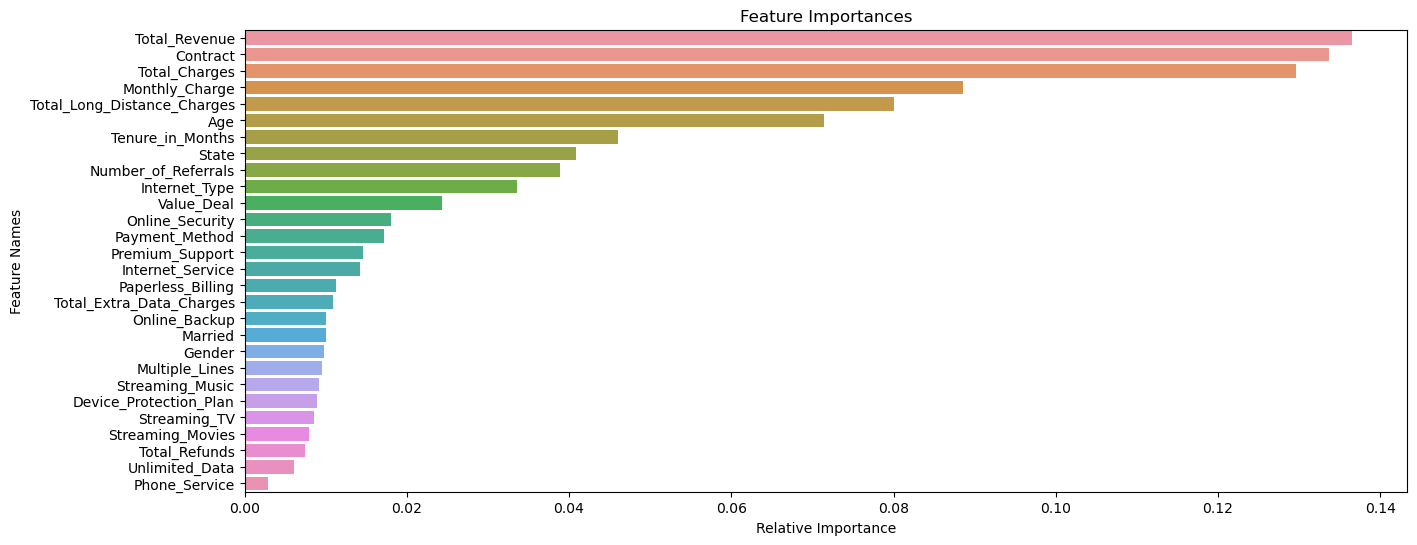

In [15]:

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

## Use Model for Prediction on New Data

In [16]:
# Read the new data
new_data = pd.read_excel('Data/Prediction_data.xlsx', sheet_name='vw_JoinData')
print(new_data.shape)
new_data.head()

(411, 32)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,81235-JHA,Female,42,Yes,Jharkhand,9,32,Deal 5,Yes,No,...,Credit Card,44.900002,44.900002,0.0,0,15.760000,60.660000,Joined,Others,Others
1,83440-GUJ,Male,53,No,Gujarat,4,14,NaN,Yes,No,...,Bank Withdrawal,20.000000,49.650002,0.0,0,93.180000,142.830002,Joined,Others,Others
2,83486-MAH,Male,34,No,Maharashtra,5,4,Deal 5,Yes,No,...,Credit Card,75.349998,75.349998,0.0,0,38.889999,114.239998,Joined,Others,Others
3,83610-BIH,Female,66,Yes,Bihar,0,11,Deal 5,Yes,No,...,Bank Withdrawal,74.199997,140.100006,0.0,0,14.580000,154.679993,Joined,Others,Others
4,84843-MAD,Female,57,Yes,Madhya Pradesh,11,8,NaN,Yes,Yes,...,Bank Withdrawal,75.099998,75.099998,0.0,0,4.530000,79.629997,Joined,Others,Others


In [17]:
# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()
original_data.shape

(411, 32)

In [18]:
# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

In [19]:
# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)
new_data.shape

(411, 28)

In [20]:
# Encode categorical variables using the saved label encoders
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

In [21]:
new_data.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
0,0,42,1,8,9,32,4,1,0,1,...,1,0,1,1,44.900002,44.900002,0.0,0,15.760000,60.660000
1,1,53,0,5,4,14,5,1,0,0,...,0,0,0,0,20.000000,49.650002,0.0,0,93.180000,142.830002
2,1,34,0,12,5,4,4,1,0,1,...,1,0,0,1,75.349998,75.349998,0.0,0,38.889999,114.239998
3,0,66,1,2,0,11,4,1,0,1,...,1,2,1,0,74.199997,140.100006,0.0,0,14.580000,154.679993
4,0,57,1,11,11,8,5,1,1,1,...,1,0,1,0,75.099998,75.099998,0.0,0,4.530000,79.629997


In [22]:
# Make predictions
new_predictions = rf_model.predict(new_data)
new_predictions

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,

In [23]:
# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions
original_data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason,Customer_Status_Predicted
0,81235-JHA,Female,42,Yes,Jharkhand,9,32,Deal 5,Yes,No,...,44.900002,44.900002,0.0,0,15.760000,60.660000,Joined,Others,Others,1
1,83440-GUJ,Male,53,No,Gujarat,4,14,NaN,Yes,No,...,20.000000,49.650002,0.0,0,93.180000,142.830002,Joined,Others,Others,0
2,83486-MAH,Male,34,No,Maharashtra,5,4,Deal 5,Yes,No,...,75.349998,75.349998,0.0,0,38.889999,114.239998,Joined,Others,Others,1
3,83610-BIH,Female,66,Yes,Bihar,0,11,Deal 5,Yes,No,...,74.199997,140.100006,0.0,0,14.580000,154.679993,Joined,Others,Others,0
4,84843-MAD,Female,57,Yes,Madhya Pradesh,11,8,NaN,Yes,Yes,...,75.099998,75.099998,0.0,0,4.530000,79.629997,Joined,Others,Others,1


In [24]:
# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]
original_data.shape

(371, 33)

In [25]:
# Save the results
original_data.to_csv(r"Data\Predictions.csv", index=False)